In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

sns.set_style("whitegrid")
import pandas as pd

# Load the dataset
df = pd.read_csv("../data/customer_churn.csv")

# Basic shape: rows and columns
print("Shape of dataset:", df.shape)

# Column names and data types
print("\nColumn info:")
df.info()

# First few rows
df.head()

Shape of dataset: (7043, 21)

Column info:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessB

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Check target variable distribution
print("\nChurn distribution:")
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)

Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [3]:
# Check if TotalCharges is actually numeric
print(df['TotalCharges'].dtype)
print(df[df['TotalCharges'] == ' '])

str
      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
488   4472-LVYGI  Female              0     Yes        Yes       0   
753   3115-CZMZD    Male              0      No        Yes       0   
936   5709-LVOEQ  Female              0     Yes        Yes       0   
1082  4367-NUYAO    Male              0     Yes        Yes       0   
1340  1371-DWPAZ  Female              0     Yes        Yes       0   
3331  7644-OMVMY    Male              0     Yes        Yes       0   
3826  3213-VVOLG    Male              0     Yes        Yes       0   
4380  2520-SGTTA  Female              0     Yes        Yes       0   
5218  2923-ARZLG    Male              0     Yes        Yes       0   
6670  4075-WKNIU  Female              0     Yes        Yes       0   
6754  2775-SEFEE    Male              0      No        Yes       0   

     PhoneService     MultipleLines InternetService       OnlineSecurity  ...  \
488            No  No phone service             DSL                  Yes  

/var/folders/y_/qn9h7yrj6kl27mx58t12h77m0000gn/T/ipykernel_38445/1756774559.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='Set2')


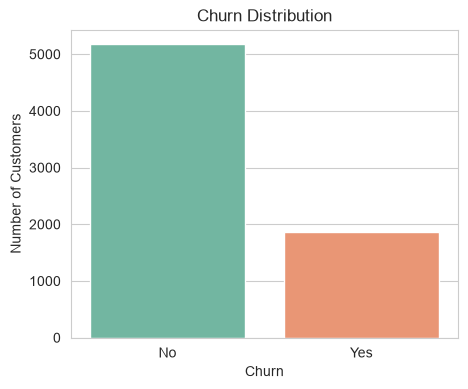

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean plot style
sns.set_style("whitegrid")

# 1. Churn distribution (count plot)
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()

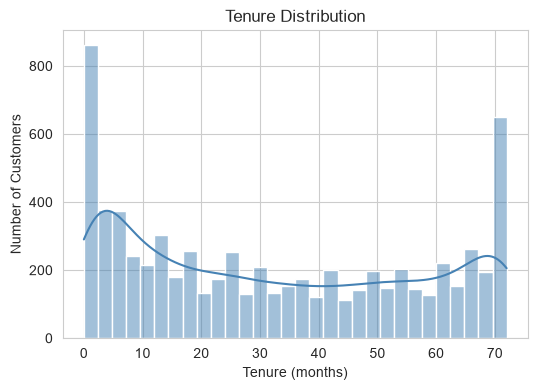

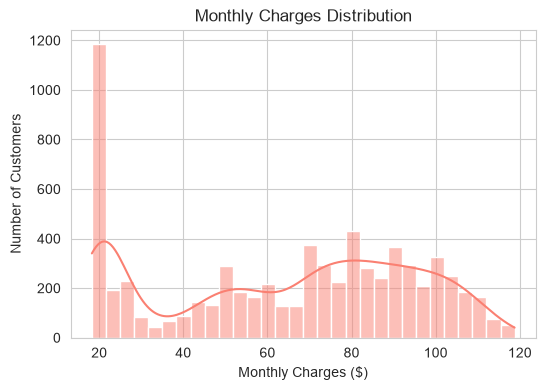

In [5]:
# 2. Tenure distribution
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='tenure', bins=30, kde=True, color='steelblue')
plt.title('Tenure Distribution')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of Customers')
plt.show()

# 3. Monthly Charges distribution
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x='MonthlyCharges', bins=30, kde=True, color='salmon')
plt.title('Monthly Charges Distribution')
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of Customers')
plt.show()

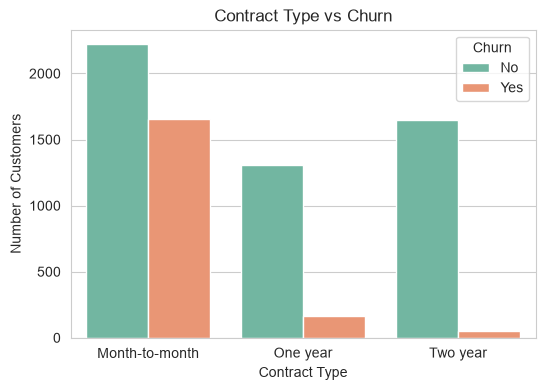

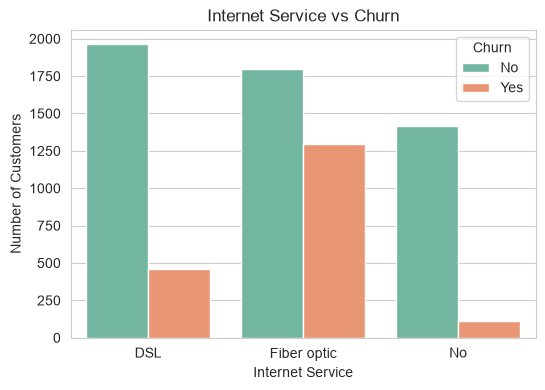

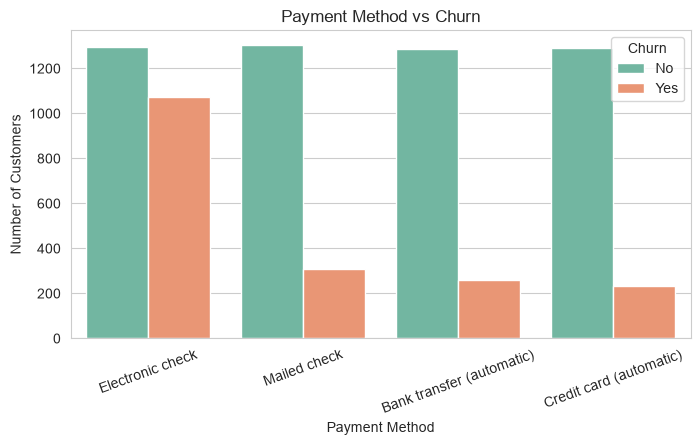

In [6]:
# 4. Contract type vs Churn
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Contract', hue='Churn', palette='Set2')
plt.title('Contract Type vs Churn')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.show()

# 5. Internet Service vs Churn
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='InternetService', hue='Churn', palette='Set2')
plt.title('Internet Service vs Churn')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.show()

# 6. Payment Method vs Churn
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='PaymentMethod', hue='Churn', palette='Set2')
plt.title('Payment Method vs Churn')
plt.xlabel('Payment Method')
plt.ylabel('Number of Customers')
plt.xticks(rotation=20)
plt.show()

/var/folders/y_/qn9h7yrj6kl27mx58t12h77m0000gn/T/ipykernel_38445/3956919226.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='tenure', palette='Set2')


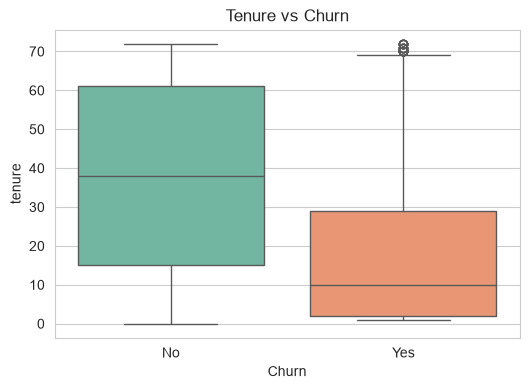

/var/folders/y_/qn9h7yrj6kl27mx58t12h77m0000gn/T/ipykernel_38445/3956919226.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set2')


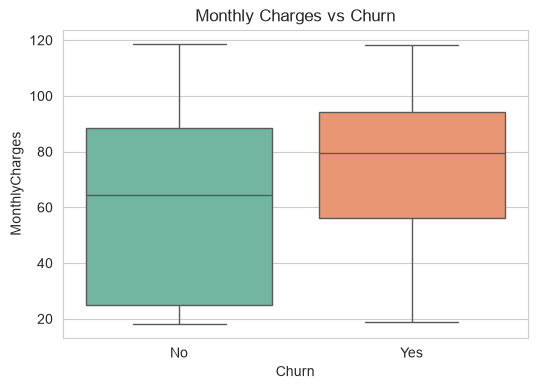

In [7]:
# 7. Tenure vs Churn
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Churn', y='tenure', palette='Set2')
plt.title('Tenure vs Churn')
plt.show()

# 8. Monthly Charges vs Churn
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set2')
plt.title('Monthly Charges vs Churn')
plt.show()

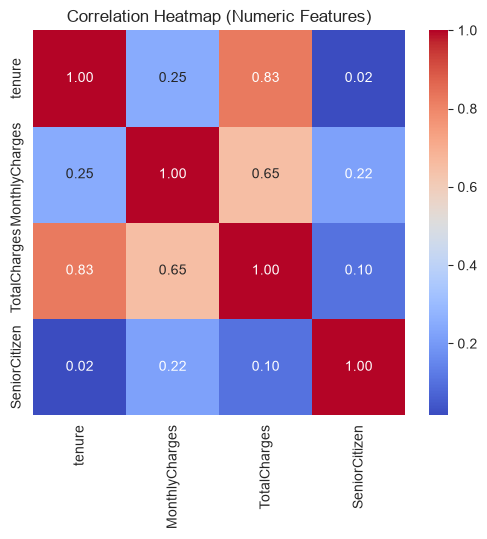

In [8]:
# 9. Correlation analysis (temporary numeric conversion of TotalCharges for this plot only)
df_numeric = df.copy()
df_numeric['TotalCharges'] = pd.to_numeric(df_numeric['TotalCharges'], errors='coerce')

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
plt.figure(figsize=(6, 5))
sns.heatmap(df_numeric[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Numeric Features)')
plt.show()

In [9]:
# Fix TotalCharges: convert to numeric, coercing blanks to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Recheck how many NaNs this created
print("Missing TotalCharges after conversion:", df['TotalCharges'].isnull().sum())

# These are the 11 customers with tenure = 0 (just signed up, no bill yet).
# We fill their TotalCharges with 0, since that's the truthful value for a brand-new customer.
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# customerID is just an identifier — it carries no predictive information and would leak
# a unique value per row, so we drop it before modeling.
df = df.drop(columns=['customerID'])

print("New shape after dropping customerID:", df.shape)

Missing TotalCharges after conversion: 11
New shape after dropping customerID: (7043, 20)


In [10]:
# Separate features (X) and target (y)
X = df.drop(columns=['Churn'])
y = df['Churn'].map({'Yes': 1, 'No': 0})

print("Features shape:", X.shape)
print("Target distribution:\n", y.value_counts())

Features shape: (7043, 19)
Target distribution:
 Churn
0    5174
1    1869
Name: count, dtype: int64


In [11]:
# Identify which columns are numeric and which are categorical
numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [col for col in X.columns if col not in numeric_features]

print("Numeric features:", numeric_features)
print("\nCategorical features:", categorical_features)
print("\nNumber of categorical features:", len(categorical_features))

Numeric features: ['tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Number of categorical features: 16


In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# ColumnTransformer applies different preprocessing to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='if_binary'), categorical_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("\nTraining churn distribution:\n", y_train.value_counts(normalize=True))
print("\nTest churn distribution:\n", y_test.value_counts(normalize=True))

Training set shape: (5634, 19)
Test set shape: (1409, 19)

Training churn distribution:
 Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Test churn distribution:
 Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [14]:
# Fit the preprocessor on TRAINING data only — this is critical to avoid data leakage
X_train_processed = preprocessor.fit_transform(X_train)

# Transform the test data using the SAME fitted preprocessor (no re-fitting!)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed training shape: (5634, 40)
Processed test shape: (1409, 40)


In [15]:
from sklearn.linear_model import LogisticRegression

# random_state ensures reproducible results
log_reg = LogisticRegression(random_state=42, max_iter=1000)

# Train on the preprocessed training data
log_reg.fit(X_train_processed, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


In [16]:
# Predict class labels (0 or 1) on the test set
y_pred_lr = log_reg.predict(X_test_processed)

# Predict probabilities (needed for ROC-AUC and risk scoring later)
y_proba_lr = log_reg.predict_proba(X_test_processed)[:, 1]  # probability of class 1 (churn)

print("Sample predictions:", y_pred_lr[:10])
print("Sample probabilities:", y_proba_lr[:10].round(3))

Sample predictions: [0 1 0 0 0 1 0 0 0 0]
Sample probabilities: [0.046 0.684 0.059 0.402 0.022 0.603 0.449 0.13  0.003 0.394]


In [17]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

# Core metrics
acc = accuracy_score(y_test, y_pred_lr)
prec = precision_score(y_test, y_pred_lr)
rec = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)
roc_auc = roc_auc_score(y_test, y_proba_lr)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print("\nFull classification report:")
print(classification_report(y_test, y_pred_lr, target_names=['No Churn', 'Churn']))

Accuracy:  0.8055
Precision: 0.6572
Recall:    0.5588
F1-score:  0.6040
ROC-AUC:   0.8420

Full classification report:
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



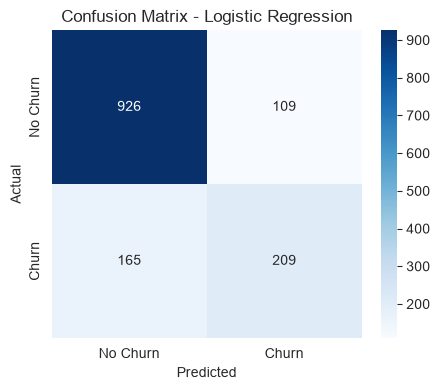

True Negatives (correctly predicted No Churn):  926
False Positives (predicted Churn, actually No):  109
False Negatives (predicted No, actually Churn):  165
True Positives (correctly predicted Churn):      209


In [18]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Manually extract TP, TN, FP, FN for clarity
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (correctly predicted No Churn):  {tn}")
print(f"False Positives (predicted Churn, actually No):  {fp}")
print(f"False Negatives (predicted No, actually Churn):  {fn}")
print(f"True Positives (correctly predicted Churn):      {tp}")

In [19]:
joblib.dump(log_reg, '../models/logistic_regression.pkl')
print("Logistic Regression model saved.")

Logistic Regression model saved.


In [20]:
from sklearn.tree import DecisionTreeClassifier

# No depth limit — let's see what happens
dt_baseline = DecisionTreeClassifier(random_state=42)
dt_baseline.fit(X_train_processed, y_train)

train_acc = dt_baseline.score(X_train_processed, y_train)
test_acc = dt_baseline.score(X_test_processed, y_test)

print(f"Baseline Tree - Training Accuracy: {train_acc:.4f}")
print(f"Baseline Tree - Test Accuracy:     {test_acc:.4f}")

Baseline Tree - Training Accuracy: 0.9980
Baseline Tree - Test Accuracy:     0.7253


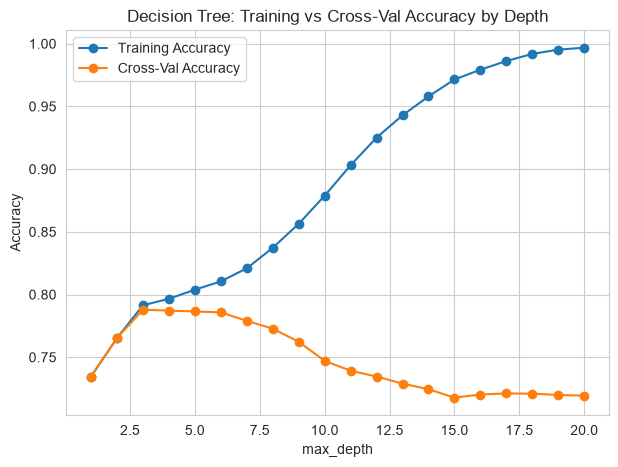

Best max_depth based on cross-validation: 3


In [21]:
from sklearn.model_selection import cross_val_score
import numpy as np

depths = range(1, 21)
train_scores = []
val_scores = []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train_processed, y_train)
    train_scores.append(dt.score(X_train_processed, y_train))
    val_scores.append(cross_val_score(dt, X_train_processed, y_train, cv=5).mean())

plt.figure(figsize=(7, 5))
plt.plot(depths, train_scores, label='Training Accuracy', marker='o')
plt.plot(depths, val_scores, label='Cross-Val Accuracy', marker='o')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree: Training vs Cross-Val Accuracy by Depth')
plt.legend()
plt.show()

best_depth = depths[np.argmax(val_scores)]
print(f"Best max_depth based on cross-validation: {best_depth}")

In [22]:
dt_model = DecisionTreeClassifier(
    max_depth=best_depth,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)
dt_model.fit(X_train_processed, y_train)

y_pred_dt = dt_model.predict(X_test_processed)
y_proba_dt = dt_model.predict_proba(X_test_processed)[:, 1]

print(f"Tuned Decision Tree Test Accuracy: {dt_model.score(X_test_processed, y_test):.4f}")

Tuned Decision Tree Test Accuracy: 0.7821


Accuracy:  0.7821
Precision: 0.6701
Recall:    0.3529
F1-score:  0.4623
ROC-AUC:   0.8183


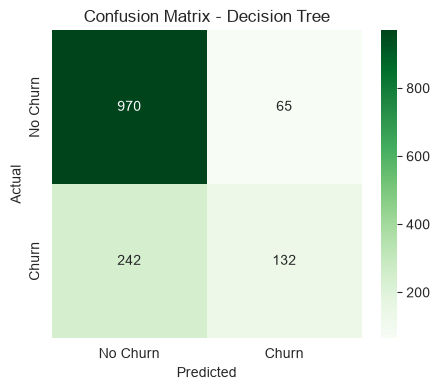

In [23]:
acc_dt = accuracy_score(y_test, y_pred_dt)
prec_dt = precision_score(y_test, y_pred_dt)
rec_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
roc_auc_dt = roc_auc_score(y_test, y_proba_dt)

print(f"Accuracy:  {acc_dt:.4f}")
print(f"Precision: {prec_dt:.4f}")
print(f"Recall:    {rec_dt:.4f}")
print(f"F1-score:  {f1_dt:.4f}")
print(f"ROC-AUC:   {roc_auc_dt:.4f}")

cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

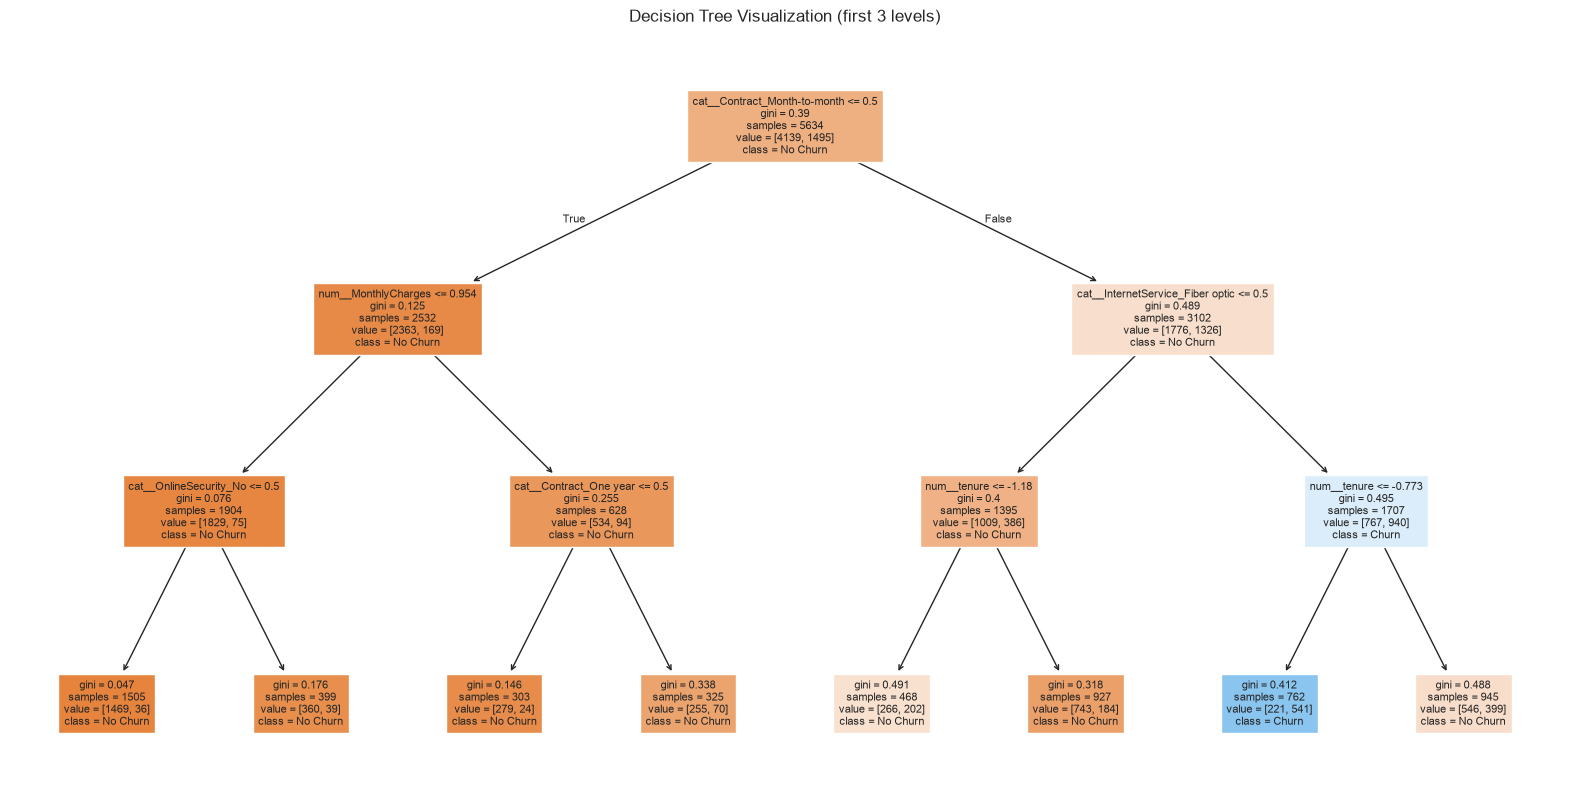

In [24]:
from sklearn.tree import plot_tree

# Get feature names after one-hot encoding, for readable labels
feature_names = preprocessor.get_feature_names_out()

plt.figure(figsize=(20, 10))
plot_tree(dt_model, max_depth=3, feature_names=feature_names,
          class_names=['No Churn', 'Churn'], filled=True, fontsize=8)
plt.title('Decision Tree Visualization (first 3 levels)')
plt.show()

In [25]:
joblib.dump(dt_model, '../models/decision_tree.pkl')
print("Decision Tree model saved.")

Decision Tree model saved.


In [26]:
from sklearn.svm import SVC

# probability=True lets us get predict_proba() later, needed for ROC-AUC and risk scoring
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_processed, y_train)

print("SVM trained successfully.")

/Users/shashanksingh/customer-churn-prediction/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVM trained successfully.


In [27]:
y_pred_svm = svm_model.predict(X_test_processed)
y_proba_svm = svm_model.predict_proba(X_test_processed)[:, 1]

acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm)
rec_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
roc_auc_svm = roc_auc_score(y_test, y_proba_svm)

print(f"Accuracy:  {acc_svm:.4f}")
print(f"Precision: {prec_svm:.4f}")
print(f"Recall:    {rec_svm:.4f}")
print(f"F1-score:  {f1_svm:.4f}")
print(f"ROC-AUC:   {roc_auc_svm:.4f}")

Accuracy:  0.7963
Precision: 0.6516
Recall:    0.5000
F1-score:  0.5658
ROC-AUC:   0.7941


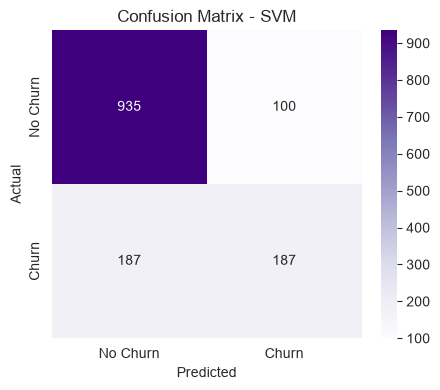

In [28]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [29]:
import joblib

joblib.dump(svm_model, '../models/svm.pkl')
print("SVM model saved.")
joblib.dump(svm_model, '../models/svm.pkl')
print("SVM model saved.")

SVM model saved.
SVM model saved.


In [30]:
from sklearn.ensemble import RandomForestClassifier

rf_baseline = RandomForestClassifier(random_state=42)
rf_baseline.fit(X_train_processed, y_train)

train_acc_rf = rf_baseline.score(X_train_processed, y_train)
test_acc_rf = rf_baseline.score(X_test_processed, y_test)

print(f"Baseline RF - Training Accuracy: {train_acc_rf:.4f}")
print(f"Baseline RF - Test Accuracy:     {test_acc_rf:.4f}")

Baseline RF - Training Accuracy: 0.9980
Baseline RF - Test Accuracy:     0.7835


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',  # optimize for F1 since we care about both precision and recall
    n_jobs=-1      # use all CPU cores to speed this up
)

rf_grid.fit(X_train_processed, y_train)

print("Best parameters:", rf_grid.best_params_)
print("Best cross-val F1 score:", rf_grid.best_score_)

In [ ]:
rf_model = rf_grid.best_estimator_

y_pred_rf = rf_model.predict(X_test_processed)
y_proba_rf = rf_model.predict_proba(X_test_processed)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)

print(f"Accuracy:  {acc_rf:.4f}")
print(f"Precision: {prec_rf:.4f}")
print(f"Recall:    {rec_rf:.4f}")
print(f"F1-score:  {f1_rf:.4f}")
print(f"ROC-AUC:   {roc_auc_rf:.4f}")

Accuracy:  0.8041
Precision: 0.6701
Recall:    0.5160
F1-score:  0.5831
ROC-AUC:   0.8411


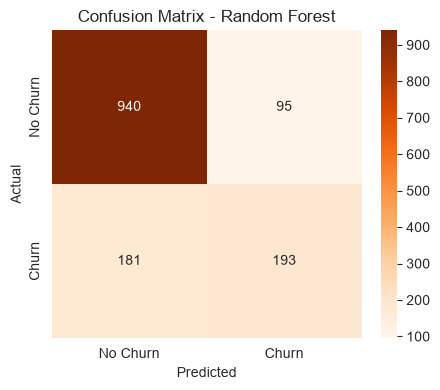

In [ ]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

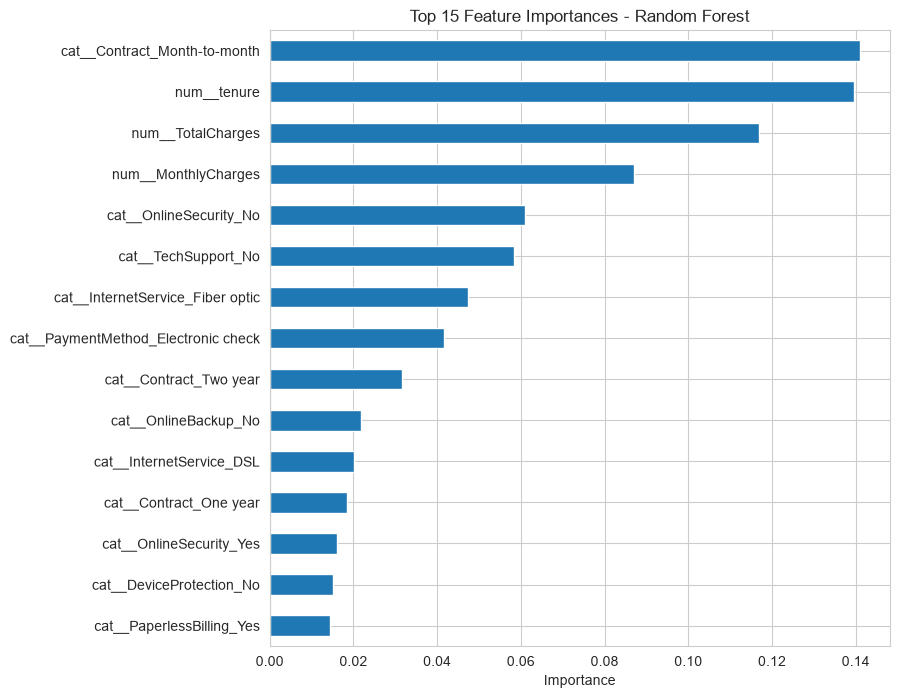

cat__Contract_Month-to-month           0.141061
num__tenure                            0.139552
num__TotalCharges                      0.116893
num__MonthlyCharges                    0.086905
cat__OnlineSecurity_No                 0.060908
cat__TechSupport_No                    0.058360
cat__InternetService_Fiber optic       0.047301
cat__PaymentMethod_Electronic check    0.041627
cat__Contract_Two year                 0.031709
cat__OnlineBackup_No                   0.021919
cat__InternetService_DSL               0.020227
cat__Contract_One year                 0.018505
cat__OnlineSecurity_Yes                0.016188
cat__DeviceProtection_No               0.015002
cat__PaperlessBilling_Yes              0.014390
dtype: float64


In [ ]:
feature_names = preprocessor.get_feature_names_out()
importances = rf_model.feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
feat_imp.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.show()

print(feat_imp.head(15))

In [ ]:
import joblib

joblib.dump(rf_model, '../models/random_forest.pkl')
print("Random Forest model saved.")
joblib.dump(rf_model, '../models/random_forest.pkl')
print("Random Forest model saved.")

Random Forest model saved.
Random Forest model saved.


In [ ]:
from sklearn.model_selection import StratifiedKFold

# StratifiedKFold preserves class distribution in every fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models_for_cv = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(max_depth=best_depth, min_samples_split=20, min_samples_leaf=10, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'Random Forest': rf_grid.best_estimator_
}

cv_results = {}

for name, model in models_for_cv.items():
    scores = cross_val_score(model, X_train_processed, y_train, cv=skf, scoring='f1')
    cv_results[name] = scores
    print(f"{name}:")
    print(f"  Fold scores: {scores.round(4)}")
    print(f"  Mean F1: {scores.mean():.4f}  |  Std Dev: {scores.std():.4f}\n")

Logistic Regression:
  Fold scores: [0.585  0.5495 0.5863 0.6425 0.5985]
  Mean F1: 0.5923  |  Std Dev: 0.0299

Decision Tree:
  Fold scores: [0.4444 0.5115 0.4747 0.4737 0.4854]
  Mean F1: 0.4780  |  Std Dev: 0.0216



/Users/shashanksingh/customer-churn-prediction/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/shashanksingh/customer-churn-prediction/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/shashanksingh/customer-churn-prediction/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/shashanksingh/customer-churn-prediction/venv/lib/pytho

SVM:
  Fold scores: [0.558  0.5585 0.5943 0.5891 0.572 ]
  Mean F1: 0.5744  |  Std Dev: 0.0151

Random Forest:
  Fold scores: [0.5693 0.5478 0.6108 0.5822 0.58  ]
  Mean F1: 0.5780  |  Std Dev: 0.0204



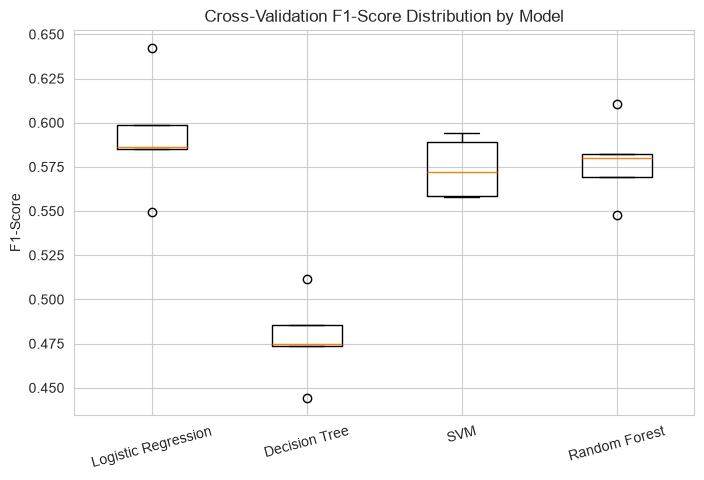

In [ ]:
plt.figure(figsize=(8, 5))
plt.boxplot(cv_results.values(), tick_labels=cv_results.keys())
plt.title('Cross-Validation F1-Score Distribution by Model')
plt.ylabel('F1-Score')
plt.xticks(rotation=15)
plt.show()

In [ ]:
cv_summary = pd.DataFrame({
    'Model': cv_results.keys(),
    'Mean F1': [scores.mean() for scores in cv_results.values()],
    'Std Dev': [scores.std() for scores in cv_results.values()]
}).sort_values('Mean F1', ascending=False)

print(cv_summary.to_string(index=False))

              Model  Mean F1  Std Dev
Logistic Regression 0.592340 0.029942
      Random Forest 0.578027 0.020414
                SVM 0.574370 0.015108
      Decision Tree 0.477956 0.021607


In [ ]:
comparison_data = {
    'Model': ['Logistic Regression', 'Decision Tree', 'SVM', 'Random Forest'],
    'Accuracy': [acc, acc_dt, acc_svm, acc_rf],
    'Precision': [prec, prec_dt, prec_svm, prec_rf],
    'Recall': [rec, rec_dt, rec_svm, rec_rf],
    'F1-Score': [f1, f1_dt, f1_svm, f1_rf],
    'ROC-AUC': [roc_auc, roc_auc_dt, roc_auc_svm, roc_auc_rf]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.round(4)

print(comparison_df.to_string(index=False))

              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression    0.8055     0.6572  0.5588    0.6040   0.8420
      Decision Tree    0.7821     0.6701  0.3529    0.4623   0.8183
                SVM    0.7963     0.6516  0.5000    0.5658   0.7941
      Random Forest    0.8041     0.6701  0.5160    0.5831   0.8411


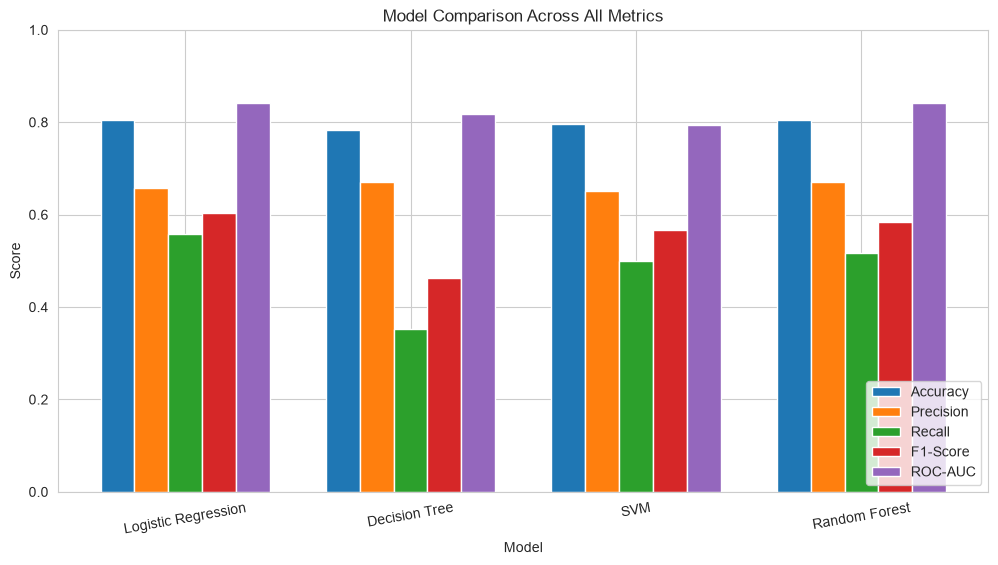

In [ ]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
x = np.arange(len(comparison_df['Model']))
width = 0.15

plt.figure(figsize=(12, 6))
for i, metric in enumerate(metrics_to_plot):
    plt.bar(x + i * width, comparison_df[metric], width, label=metric)

plt.xlabel('Model')
plt.ylabel('Score')
plt.title('Model Comparison Across All Metrics')
plt.xticks(x + width * 2, comparison_df['Model'], rotation=10)
plt.legend(loc='lower right')
plt.ylim(0, 1)
plt.show()

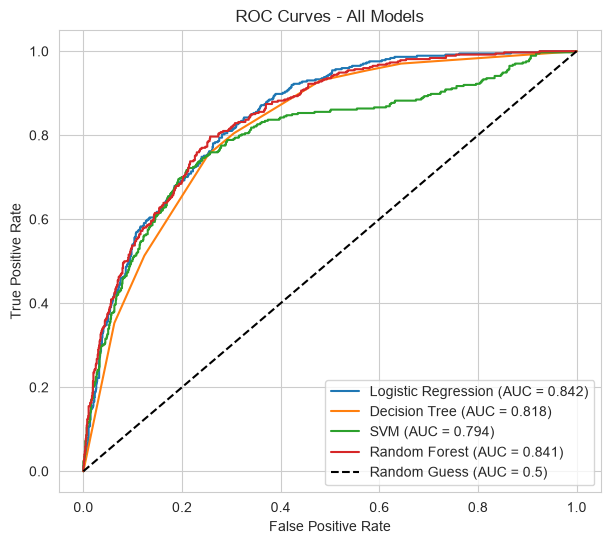

In [ ]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(7, 6))

models_proba = {
    'Logistic Regression': y_proba_lr,
    'Decision Tree': y_proba_dt,
    'SVM': y_proba_svm,
    'Random Forest': y_proba_rf
}

for name, proba in models_proba.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_score = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend(loc='lower right')
plt.show()

## Model Comparison Discussion

While Random Forest and SVM achieve comparable or slightly better precision in some cases, 
Logistic Regression achieves the best overall balance across metrics, particularly the 
highest ROC-AUC and F1-score, and this was confirmed by cross-validation (Step 9), where 
it also had the best mean F1-score across 5 folds.

However, "best" depends on business priorities:
- If minimizing false negatives (missed churners) is the priority, the model with the 
  highest **recall** should be preferred, even at the cost of more false alarms.
- If minimizing wasted retention-outreach cost is the priority, the model with the 
  highest **precision** should be preferred.
- ROC-AUC gives a threshold-independent view of overall ranking quality, useful when the 
  final decision threshold (0.5, or another value) hasn't been fixed yet.

We do not declare a single model "best" purely based on accuracy, since accuracy alone 
can be misleading on this imbalanced dataset (73.5% No Churn / 26.5% Churn).

In [ ]:
# Select features relevant to customer segmentation
# We reuse the original df (before one-hot encoding) since we want a small, interpretable feature set
cluster_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_cluster = df[cluster_features].copy()

print("Missing values in clustering features:")
print(X_cluster.isnull().sum())
print("\nSummary statistics:")
print(X_cluster.describe())

Missing values in clustering features:
tenure            0
MonthlyCharges    0
TotalCharges      0
dtype: int64

Summary statistics:
            tenure  MonthlyCharges  TotalCharges
count  7043.000000     7043.000000   7043.000000
mean     32.371149       64.761692   2279.734304
std      24.559481       30.090047   2266.794470
min       0.000000       18.250000      0.000000
25%       9.000000       35.500000    398.550000
50%      29.000000       70.350000   1394.550000
75%      55.000000       89.850000   3786.600000
max      72.000000      118.750000   8684.800000


In [ ]:
from sklearn.preprocessing import StandardScaler

cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

print("Scaled feature shape:", X_cluster_scaled.shape)
print("Mean after scaling (should be ~0):", X_cluster_scaled.mean(axis=0).round(3))
print("Std after scaling (should be ~1):", X_cluster_scaled.std(axis=0).round(3))

Scaled feature shape: (7043, 3)
Mean after scaling (should be ~0): [-0. -0. -0.]
Std after scaling (should be ~1): [1. 1. 1.]


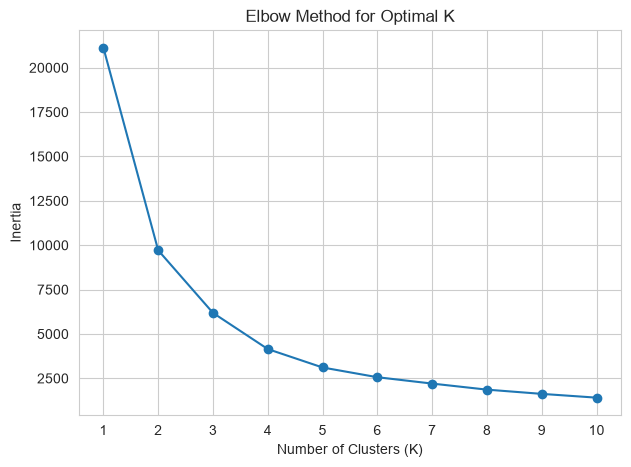

In [ ]:
from sklearn.cluster import KMeans

inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_cluster_scaled)
    inertias.append(kmeans_temp.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(K_range, inertias, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(K_range)
plt.show()

K=2: Silhouette Score = 0.4797
K=3: Silhouette Score = 0.4515
K=4: Silhouette Score = 0.4722
K=5: Silhouette Score = 0.4437
K=6: Silhouette Score = 0.4397
K=7: Silhouette Score = 0.4501
K=8: Silhouette Score = 0.4247
K=9: Silhouette Score = 0.4337
K=10: Silhouette Score = 0.4349


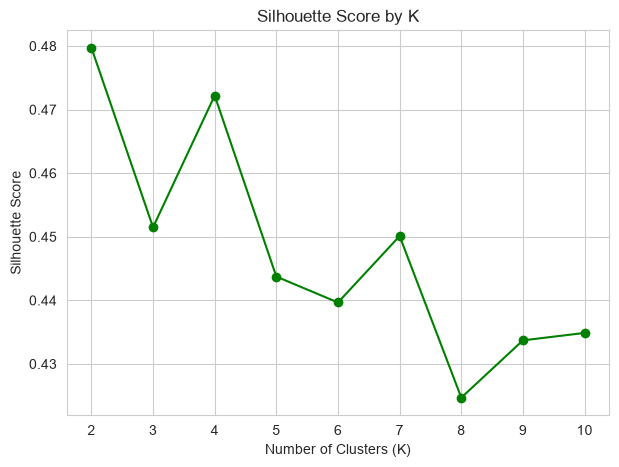

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
K_range_sil = range(2, 11)  # silhouette score is undefined for K=1

for k in K_range_sil:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_temp = kmeans_temp.fit_predict(X_cluster_scaled)
    score = silhouette_score(X_cluster_scaled, labels_temp)
    silhouette_scores.append(score)
    print(f"K={k}: Silhouette Score = {score:.4f}")

plt.figure(figsize=(7, 5))
plt.plot(K_range_sil, silhouette_scores, marker='o', color='green')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by K')
plt.xticks(K_range_sil)
plt.show()

In [ ]:
optimal_k = 4

kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans_model.fit_predict(X_cluster_scaled)

# Add cluster assignment back to a copy of the original (unscaled) data for interpretation
df_clustered = df.copy()
df_clustered['Cluster'] = cluster_labels

print("Cluster sizes:")
print(df_clustered['Cluster'].value_counts().sort_index())

Cluster sizes:
Cluster
0    1703
1    1904
2    2276
3    1160
Name: count, dtype: int64


In [ ]:
cluster_profile = df_clustered.groupby('Cluster')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean().round(2)
cluster_profile['Count'] = df_clustered['Cluster'].value_counts().sort_index()

# Also check churn rate per cluster (for context — NOT used to build the clusters)
cluster_profile['Churn Rate (%)'] = (df_clustered.groupby('Cluster')['Churn']
                                       .apply(lambda x: (x == 'Yes').mean() * 100)
                                       .round(2))

print(cluster_profile)

         tenure  MonthlyCharges  TotalCharges  Count  Churn Rate (%)
Cluster                                                             
0         10.21           31.78        302.15   1703           24.66
1         59.53           93.31       5548.65   1904           15.39
2         15.42           80.78       1251.17   2276           48.24
3         53.57           34.91       1835.62   1160            5.00


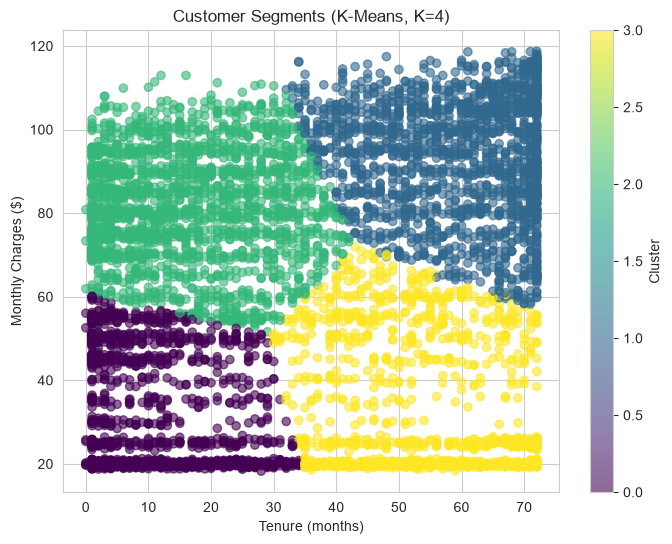

In [ ]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df_clustered['tenure'], df_clustered['MonthlyCharges'],
                       c=df_clustered['Cluster'], cmap='viridis', alpha=0.6)
plt.xlabel('Tenure (months)')
plt.ylabel('Monthly Charges ($)')
plt.title('Customer Segments (K-Means, K=4)')
plt.colorbar(scatter, label='Cluster')
plt.show()

In [ ]:
joblib.dump(kmeans_model, '../models/kmeans_model.pkl')
joblib.dump(cluster_scaler, '../models/cluster_scaler.pkl')
print("K-Means model and scaler saved.")

K-Means model and scaler saved.


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster_scaled)

print("Explained variance ratio per component:", pca.explained_variance_ratio_.round(4))
print("Cumulative explained variance:", pca.explained_variance_ratio_.cumsum().round(4))

Explained variance ratio per component: [0.7269 0.2533]
Cumulative explained variance: [0.7269 0.9801]


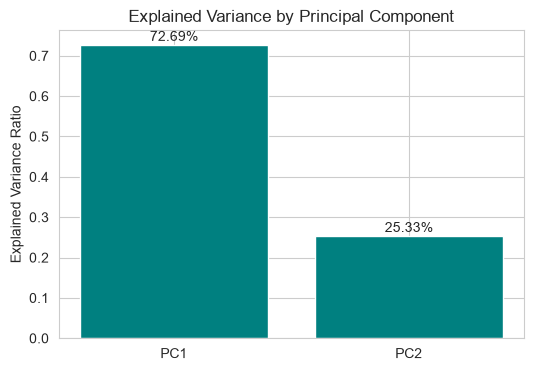

In [ ]:
plt.figure(figsize=(6, 4))
components = ['PC1', 'PC2']
plt.bar(components, pca.explained_variance_ratio_, color='teal')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Principal Component')
for i, v in enumerate(pca.explained_variance_ratio_):
    plt.text(i, v + 0.01, f'{v:.2%}', ha='center')
plt.show()

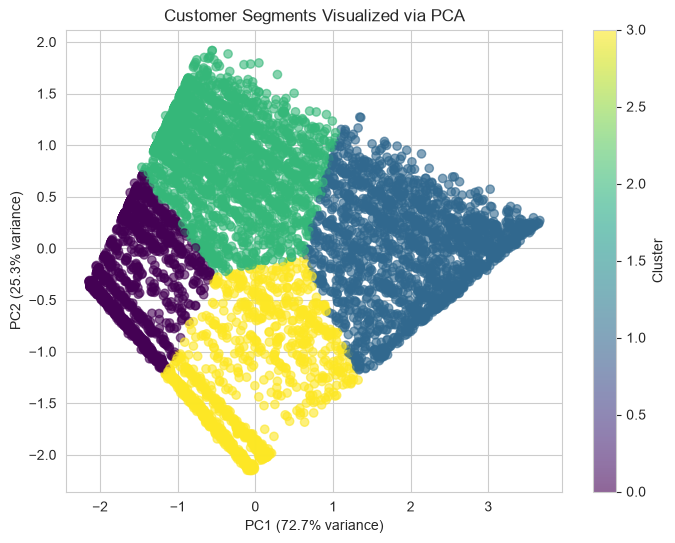

In [ ]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.6)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('Customer Segments Visualized via PCA')
plt.colorbar(scatter, label='Cluster')
plt.show()

In [ ]:
joblib.dump(pca, '../models/pca_model.pkl')
print("PCA model saved.")

PCA model saved.


In [ ]:
print(list(X.columns))
print(X.dtypes)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
dtype: object


In [ ]:
categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                     'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                     'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
                     'PaperlessBilling', 'PaymentMethod']

for col in categorical_cols:
    print(f"{col}: {sorted(df[col].unique())}")

gender: ['Female', 'Male']
Partner: ['No', 'Yes']
Dependents: ['No', 'Yes']
PhoneService: ['No', 'Yes']
MultipleLines: ['No', 'No phone service', 'Yes']
InternetService: ['DSL', 'Fiber optic', 'No']
OnlineSecurity: ['No', 'No internet service', 'Yes']
OnlineBackup: ['No', 'No internet service', 'Yes']
DeviceProtection: ['No', 'No internet service', 'Yes']
TechSupport: ['No', 'No internet service', 'Yes']
StreamingTV: ['No', 'No internet service', 'Yes']
StreamingMovies: ['No', 'No internet service', 'Yes']
Contract: ['Month-to-month', 'One year', 'Two year']
PaperlessBilling: ['No', 'Yes']
PaymentMethod: ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']


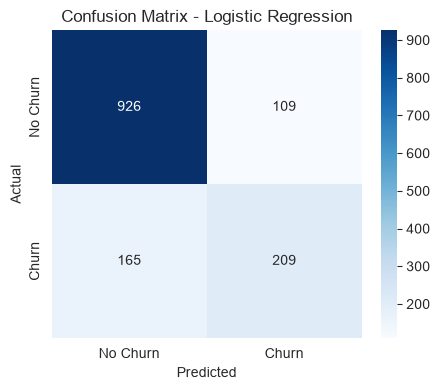

In [ ]:
cm_lr_final = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lr_final, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('../static/images/cm_logistic_regression.png', bbox_inches='tight', dpi=100)
plt.show()

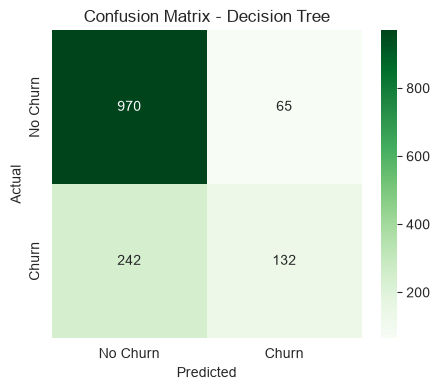

In [ ]:
cm_dt_final = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_dt_final, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('../static/images/cm_decision_tree.png', bbox_inches='tight', dpi=100)
plt.show()

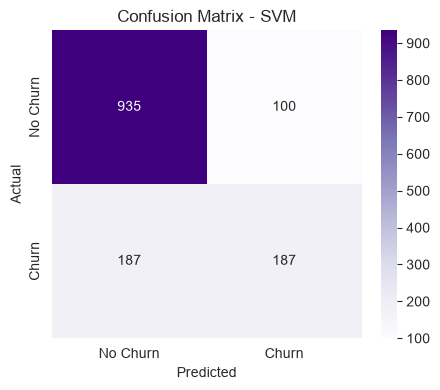

In [ ]:
cm_svm_final = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_svm_final, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('../static/images/cm_svm.png', bbox_inches='tight', dpi=100)
plt.show()

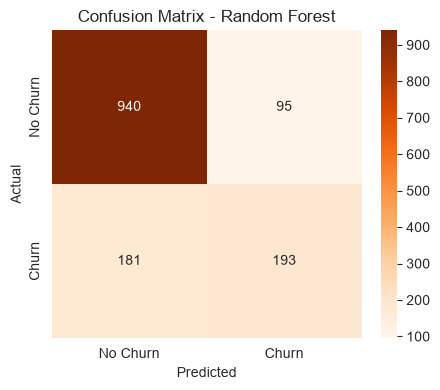

In [ ]:
cm_rf_final = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf_final, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('../static/images/cm_random_forest.png', bbox_inches='tight', dpi=100)
plt.show()

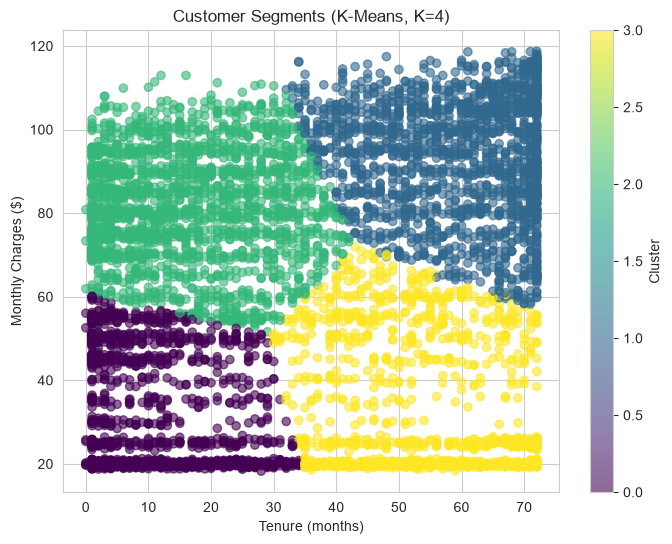

In [ ]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df_clustered['tenure'], df_clustered['MonthlyCharges'],
                       c=df_clustered['Cluster'], cmap='viridis', alpha=0.6)
plt.xlabel('Tenure (months)')
plt.ylabel('Monthly Charges ($)')
plt.title('Customer Segments (K-Means, K=4)')
plt.colorbar(scatter, label='Cluster')
plt.savefig('../static/images/cluster_scatter.png', bbox_inches='tight', dpi=100)
plt.show()

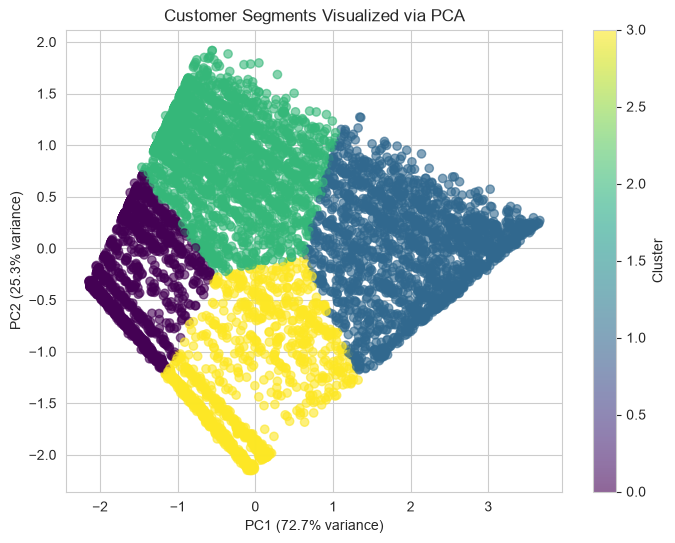

In [ ]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.6)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('Customer Segments Visualized via PCA')
plt.colorbar(scatter, label='Cluster')
plt.savefig('../static/images/pca_scatter.png', bbox_inches='tight', dpi=100)
plt.show()